# Logistic Regression for Customer Churn Prediction

## Objective

The objective of this project is to implement a Logistic Regression model to predict whether a customer will churn or not.

The project includes data preprocessing, exploratory data analysis, model training, evaluation using classification metrics and ROC curve, and interpretation of model coefficients using odds ratios.

### Key Tasks

* Load and preprocess the customer churn dataset
* Perform exploratory data analysis
* Train a Logistic Regression model using scikit-learn
* Evaluate the model using Accuracy, Precision, Recall, and ROC-AUC
* Interpret Logistic Regression coefficients
* Calculate and interpret odds ratios


## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, model training, and evaluation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

## 2. Load the Dataset

The Churn BIGML80 dataset contains customer information along with a binary churn outcome. The target variable indicates whether a customer has churned or not.


In [2]:
df = pd.read_csv("churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 3. Dataset Overview

The dataset contains customer information such as account length, area code, international plan, voicemail plan, call usage, international usage, and customer service calls.

The target variable is `Churn`, which indicates whether a customer has discontinued the service.

* `False` → Customer did not churn
* `True` → Customer churned

Since the target contains two possible outcomes, this is a binary classification problem suitable for Logistic Regression.


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2666, 20)

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [5]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## 4. Check Missing Values and Duplicates

Missing values and duplicate records are checked before proceeding with model development.


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 5. Target Variable Distribution

Before training the model, the distribution of the target variable is examined to understand the proportion of customers who churned and those who did not churn.


In [8]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
False    2278
True      388
Name: count, dtype: int64

Churn Percentage:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


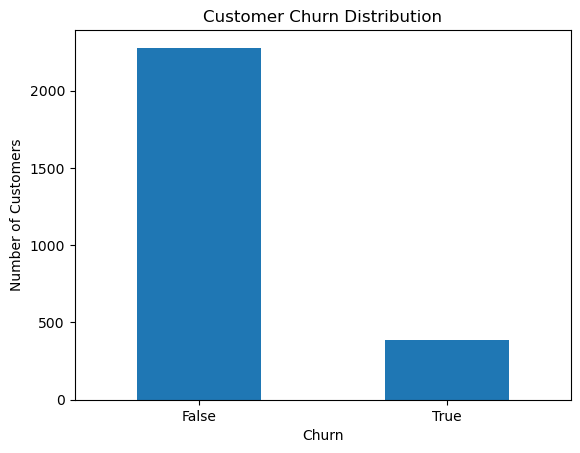

In [9]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Observation

The dataset contains more customers who did not churn than customers who churned. Approximately 85.45% of customers did not churn, while 14.55% churned.

This indicates a class imbalance in the target variable. Therefore, accuracy alone is not sufficient for evaluating the model. Precision, recall, F1-score, and ROC-AUC will also be considered.


## 6. Data Preprocessing

The target variable `Churn` is converted from Boolean values into binary numerical values:

* `False` → 0 (No Churn)
* `True` → 1 (Churn)

The categorical features are encoded using One-Hot Encoding, while numerical features are standardized using StandardScaler.

The dataset is split into training and testing sets before fitting the preprocessing transformations to avoid data leakage.


In [10]:
df["Churn"] = df["Churn"].astype(int)

df["Churn"].value_counts()

Churn
0    2278
1     388
Name: count, dtype: int64

## 7. Define Features and Target

The `Churn` column is used as the target variable, while all remaining columns are used as input features.


In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2666, 19)
Target Shape: (2666,)


## 8. Identify Numerical and Categorical Features

The dataset contains both numerical and categorical variables. These feature types require different preprocessing techniques.


In [12]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['State', 'International plan', 'Voice mail plan']

Numerical Features:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


## 9. Train-Test Split

The dataset is divided into training and testing sets. Eighty percent of the data is used for training and twenty percent is reserved for testing.

Stratified splitting is used to maintain a similar proportion of churn and non-churn customers in both sets.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (2132, 19)
Testing Set Shape: (534, 19)


## 10. Create Preprocessing Pipeline

Numerical features are standardized using `StandardScaler`, while categorical features are converted into numerical variables using `OneHotEncoder`.

A `ColumnTransformer` is used to apply the appropriate preprocessing method to each feature type.


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
       ("cat", OneHotEncoder(
          drop="first",
          handle_unknown="ignore"
       ), categorical_features)
    ]
)

## 11. Build Logistic Regression Model

A Logistic Regression model is used because the target variable has two possible outcomes: churn and no churn.

The preprocessing steps and Logistic Regression model are combined into a single pipeline.


In [15]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12. Make Predictions

The trained model is used to predict the churn status of customers in the test dataset.

Both class predictions and churn probabilities are generated. The probabilities will later be used to construct the ROC curve.


In [16]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Churn Probabilities:")
print(y_prob[:10])

Predicted Classes:
[0 0 0 0 0 0 0 0 0 0]

Predicted Churn Probabilities:
[0.00895378 0.09306618 0.01325812 0.24879327 0.02428766 0.15585776
 0.17030247 0.14729132 0.34723555 0.17888402]


## 13. Model Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

These metrics provide a more complete evaluation because the dataset contains an imbalance between churned and non-churned customers.


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8427
Precision: 0.4211
Recall   : 0.2051
F1 Score : 0.2759
ROC-AUC  : 0.7408


### Model Performance Summary

The Logistic Regression model achieved an accuracy of 84.27%. The precision was 42.11%, while the recall was 20.51%. The F1-score was 27.59% and the ROC-AUC score was 0.7408.

The relatively lower recall indicates that the model does not identify all customers who actually churn. This is important because the dataset contains a class imbalance, with considerably more non-churning customers than churning customers.

In [18]:
print("Classification Report")
print("----------------------")
print(classification_report(y_test, y_pred))

Classification Report
----------------------
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       456
           1       0.42      0.21      0.28        78

    accuracy                           0.84       534
   macro avg       0.65      0.58      0.59       534
weighted avg       0.81      0.84      0.82       534



## 14. Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified customers for each class.


In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[434  22]
 [ 62  16]]


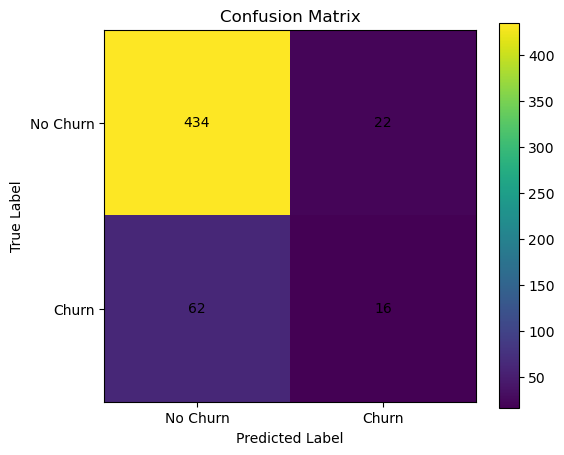

In [20]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

### Observation

The confusion matrix shows that the model correctly classified most customers who did not churn. However, a number of customers who actually churned were classified as non-churners.

This results in a relatively low recall for the churn class, indicating that the model has difficulty identifying some customers who are likely to churn.

### Observation

The confusion matrix shows that the model correctly classified 433 customers who did not churn and 17 customers who churned. It incorrectly classified 23 non-churning customers as churners and failed to identify 61 customers who actually churned.

The relatively high number of false negatives indicates that the model has difficulty identifying some customers who are likely to churn. This is reflected in the lower recall score of 0.2179.

## 15. ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to distinguish between customers who churn and customers who do not churn at different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discriminative ability of the model.


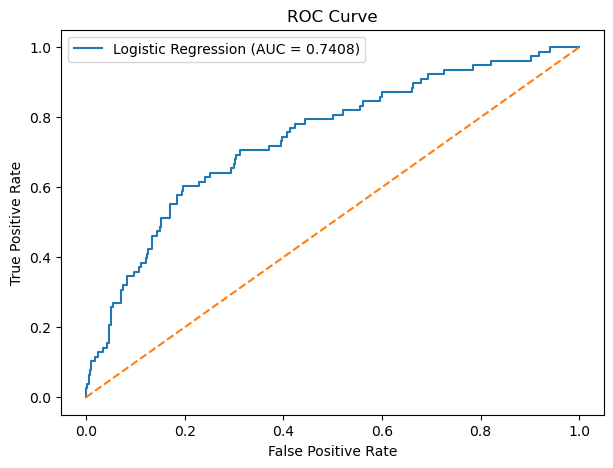

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Observation

The Logistic Regression model achieved an ROC-AUC score of 0.7408. The ROC curve lies above the diagonal reference line, indicating that the model performs better than random classification and has a reasonable ability to distinguish between customers who churn and those who do not.

### Observation

The Logistic Regression model achieved an ROC-AUC score of 0.7435. The ROC curve lies above the diagonal reference line, indicating that the model performs better than random classification and has a reasonable ability to distinguish between customers who churn and those who do not.

## 16. Logistic Regression Coefficients

Logistic Regression coefficients indicate how the input features are associated with the log-odds of customer churn.

- A positive coefficient indicates higher odds of churn.
- A negative coefficient indicates lower odds of churn.
- A coefficient close to zero indicates a relatively smaller effect on the log-odds.

Numerical features were standardized before training. Therefore, their coefficients represent the effect associated with a one-standard-deviation increase in the corresponding feature.

For categorical features, one-hot encoding with `drop="first"` is used, allowing the encoded categories to be interpreted relative to their reference categories.

In [22]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = logistic_model.named_steps["classifier"].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient
66,cat__International plan_Yes,2.375495
58,cat__State_TX,1.376106
41,cat__State_MT,0.932028
15,num__Customer service calls,0.793123
37,cat__State_MI,0.791985
...,...,...
51,cat__State_OK,-0.731588
26,cat__State_HI,-0.800679
60,cat__State_VA,-0.908408
67,cat__Voice mail plan_Yes,-0.948364


## 17. Odds Ratios

Odds ratios are obtained by exponentiating the Logistic Regression coefficients.

**Odds Ratio = exp(Coefficient)**

- Odds Ratio > 1 → higher odds of churn
- Odds Ratio < 1 → lower odds of churn
- Odds Ratio = 1 → no change in the odds of churn

For standardized numerical features, the odds ratio represents the change in churn odds associated with a one-standard-deviation increase in the feature, while keeping other variables constant.

For one-hot encoded categorical features, the odds ratio represents the change in churn odds relative to the reference category, while keeping other variables constant.

In [23]:
coefficient_df["Odds Ratio"] = np.exp(coefficient_df["Coefficient"])

coefficient_df

,Feature,Coefficient,Odds Ratio
66,cat__International plan_Yes,2.375495,10.756335
58,cat__State_TX,1.376106,3.959454
41,cat__State_MT,0.932028,2.539654
15,num__Customer service calls,0.793123,2.210288
37,cat__State_MI,0.791985,2.207775
...,...,...,...
51,cat__State_OK,-0.731588,0.481144
26,cat__State_HI,-0.800679,0.449024
60,cat__State_VA,-0.908408,0.403165
67,cat__Voice mail plan_Yes,-0.948364,0.387374


## 18. Most Important Features Based on Coefficients

The features with the largest positive and negative coefficients are examined to identify variables most strongly associated with customer churn.


In [24]:
top_positive = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

top_negative = coefficient_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

print("Top Positive Coefficients:")
display(top_positive)

print("\nTop Negative Coefficients:")
display(top_negative)

Top Positive Coefficients:


,Feature,Coefficient,Odds Ratio
66,cat__International plan_Yes,2.375495,10.756335
58,cat__State_TX,1.376106,3.959454
41,cat__State_MT,0.932028,2.539654
15,num__Customer service calls,0.793123,2.210288
37,cat__State_MI,0.791985,2.207775
46,cat__State_NJ,0.783044,2.188123
40,cat__State_MS,0.762516,2.143662
55,cat__State_SC,0.749092,2.115078
62,cat__State_WA,0.686996,1.987735
38,cat__State_MN,0.620146,1.859199



Top Negative Coefficients:


,Feature,Coefficient,Odds Ratio
54,cat__State_RI,-1.042312,0.352638
67,cat__Voice mail plan_Yes,-0.948364,0.387374
60,cat__State_VA,-0.908408,0.403165
26,cat__State_HI,-0.800679,0.449024
51,cat__State_OK,-0.731588,0.481144
63,cat__State_WI,-0.653604,0.520168
42,cat__State_NC,-0.634674,0.530108
29,cat__State_IL,-0.601199,0.548154
28,cat__State_ID,-0.596384,0.550800
18,cat__State_AZ,-0.545116,0.579774


## 19. Interpretation of Odds Ratios

The odds ratios provide an interpretable way to understand the relationship between customer characteristics and the likelihood of churn.

For example, `International plan_Yes` has an odds ratio of approximately 10.76. This indicates that customers with an international plan have approximately 10.76 times higher estimated odds of churn compared with the reference category, while keeping other variables constant.

The `Customer service calls` feature has an odds ratio of approximately 2.21. Since the numerical features were standardized, this indicates that a one-standard-deviation increase in customer service calls is associated with approximately 2.21 times higher estimated odds of churn, holding other variables constant.

The `Voice mail plan_Yes` feature has an odds ratio of approximately 0.39, indicating lower estimated odds of churn compared with its reference category.

These results describe associations learned by the model and should not be interpreted as evidence of direct causation.

## 20. Conclusion

A Logistic Regression model was successfully developed to predict customer churn using the Churn BIGML80 dataset.

The dataset was preprocessed by converting the target variable into binary values, standardizing numerical features, and applying one-hot encoding to categorical features. A train-test split with stratification was used to maintain the class distribution.

The model achieved an accuracy of 84.27%, precision of 42.11%, recall of 20.51%, F1-score of 27.59%, and ROC-AUC of 0.7408.

The confusion matrix showed that the model identifies most non-churning customers correctly but misses a number of actual churners. The ROC curve indicates that the model has a reasonable ability to distinguish between churned and non-churned customers.

Finally, Logistic Regression coefficients and odds ratios were analyzed to understand the association between customer characteristics and churn. This demonstrates both the predictive and interpretability aspects of Logistic Regression for binary classification.